# Predicting `bottom10` — first-pass replication of the Chelsea model

**Goal:** predict whether a Dallas multitenant property has ever been in the bottom 10% of inspection scores (`bottom10`), using property/neighborhood features.

This notebook is a **skeleton**. The section headers mirror the Chelsea pipeline; the code is yours to write. Before you start, read:
- [`_docs/data_dictionary.md`](../_docs/data_dictionary.md) — which columns are usable features vs. leakage (important!)
- [`_docs/chelsea_methodology.md`](../_docs/chelsea_methodology.md) — what the original study did

Work through the README's "First tasks" list, one pull request per section.

## 1. Load the data

Run this cell to confirm your environment and data are set up. It should print `(2798, 33)`. If you get a `FileNotFoundError`, copy `properties_with_acs.csv` into the `_data/` folder (see [SETUP.md](../SETUP.md)).

In [1]:
import pandas as pd

df = pd.read_csv("../_data/properties_with_acs.csv")
print(df.shape)
df.head()

(2798, 33)


,address,account_name,sr_owner,score_current,score_min,score_max,score_mean,n_inspections,n_bottom10,life_hazard,...,lat,pct_poverty,pct_renter,pct_hispanic,pct_nh_black,pct_nh_white,pct_nh_asian,pct_foreign_born,pct_rent_burden_30,pct_rent_burden_35
0,"100 N EDGEFIELD AVE, DALLAS, TX, 75208",APARTMENTS,Multi-Family,99.0,99.0,100.0,99.500000,2,0,0,...,32.745309,6.8,54.3,33.7,7.5,50.5,2.6,7.1,64.0,40.9
1,"100 N HENDERSON AVE, DALLAS, TX, 75214",LAKEWOOD ON HENDERSON,Multi-Family,100.0,39.0,100.0,79.333336,3,1,0,...,32.798974,31.6,67.2,18.7,37.6,41.8,0.7,8.4,42.4,38.2
2,"100 N RANDOLPH DR, DALLAS, TX, 75211",CASA LOMA,Multi-Family,63.0,63.0,100.0,85.666664,3,1,0,...,32.745572,28.4,40.8,96.6,0.2,2.8,0.0,37.3,37.5,31.2
3,"1000 GRIGSBY AVE, DALLAS, TX, 75204",APARTMENTS,Multi-Family,87.0,87.0,90.0,88.500000,2,0,0,...,32.799587,13.0,81.4,29.7,17.6,43.4,6.1,12.5,37.3,26.7
4,"10000 WALNUT ST, DALLAS, TX, 75243",PARKS AT WALNUT,Multi-Family,95.0,90.0,96.0,94.250000,4,0,1,...,32.917910,28.2,72.0,33.0,46.0,12.4,6.6,52.1,70.5,63.0


In [12]:
## 2. EDA

#_TODO:_ What share of properties are `bottom10`? Plot distributions of the candidate features. Check for missing values. (Task 3 in the README.)

# Share of properties that are bottom10
bottom10_share = df['bottom10'].mean()
bottom10_share
float(bottom10_share)

# Missing values by column (count)
df.isna().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().sum() / len(df)) * 100
}).sort_values('missing_count', ascending=False)
missing_df




,missing_count,missing_percent
score_current,13,0.464618
sr_owner,8,0.285919
score_min,4,0.142959
score_max,4,0.142959
score_mean,4,0.142959
score_range,4,0.142959
bottom10,4,0.142959
address,1,0.035740
pct_renter,1,0.035740
lon,1,0.035740


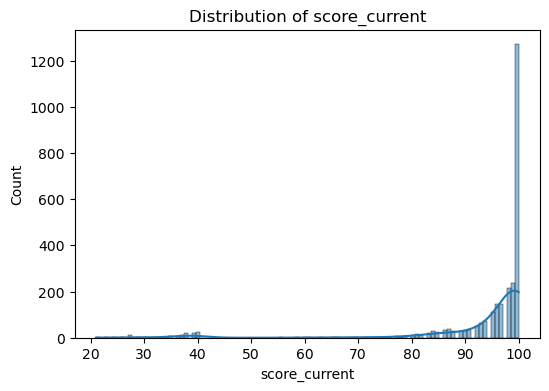

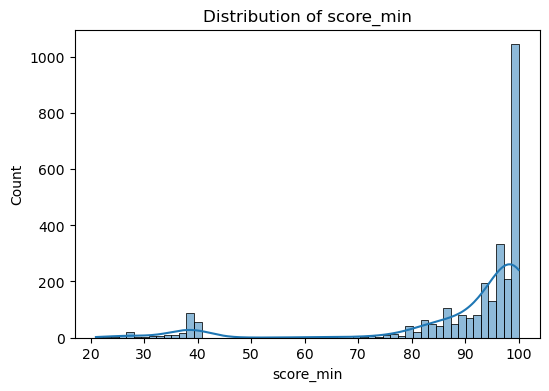

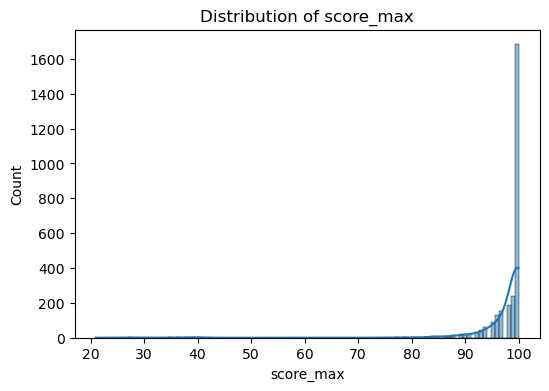

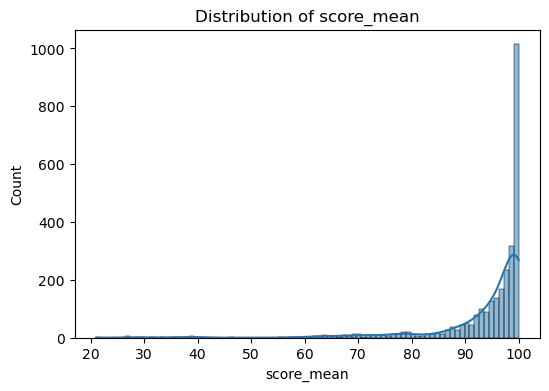

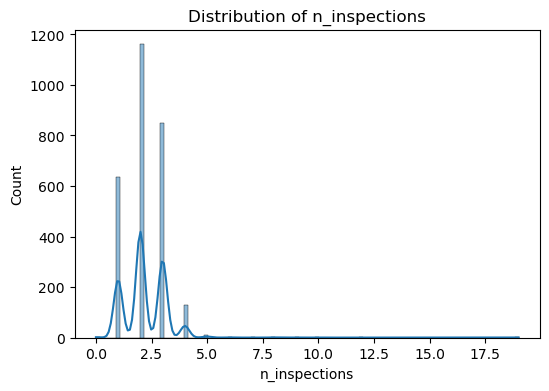

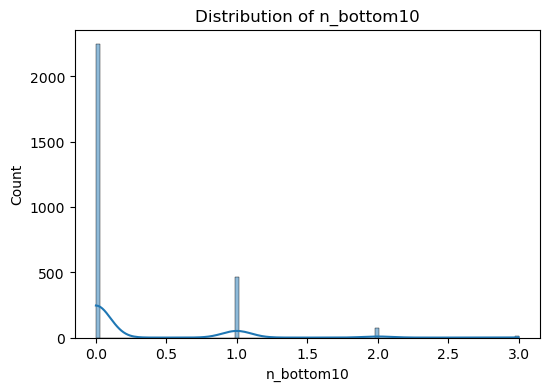

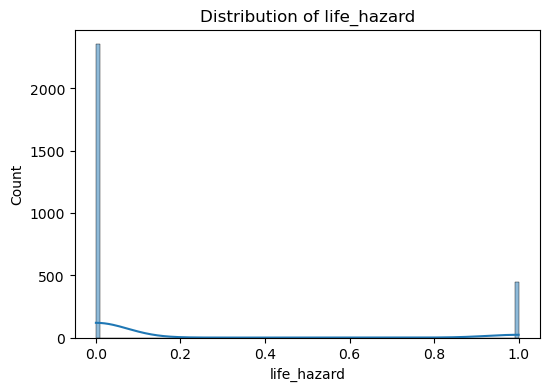

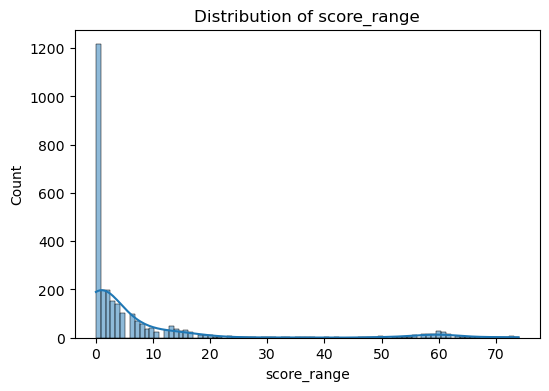

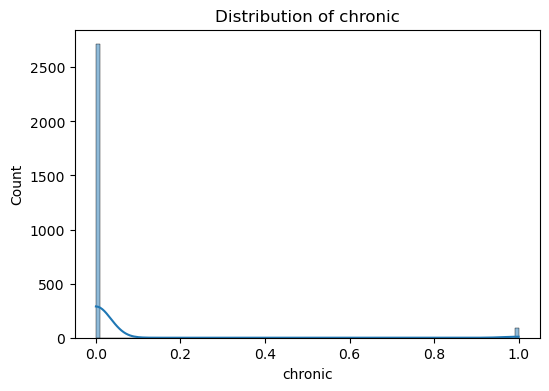

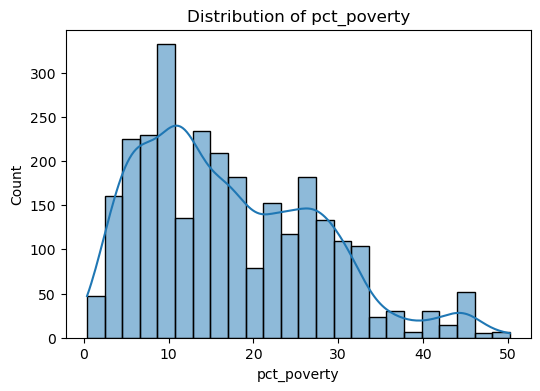

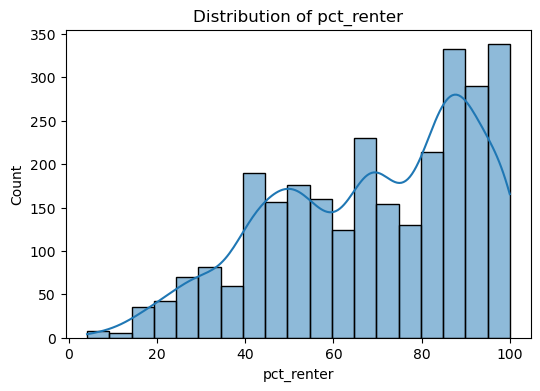

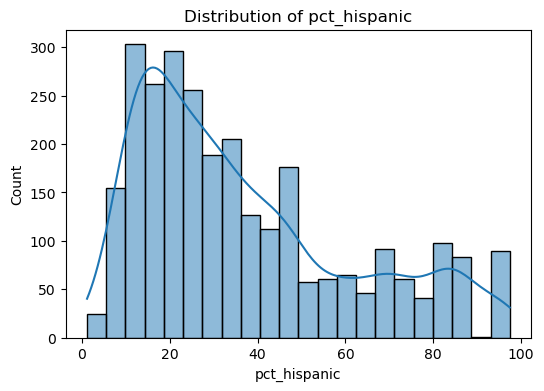

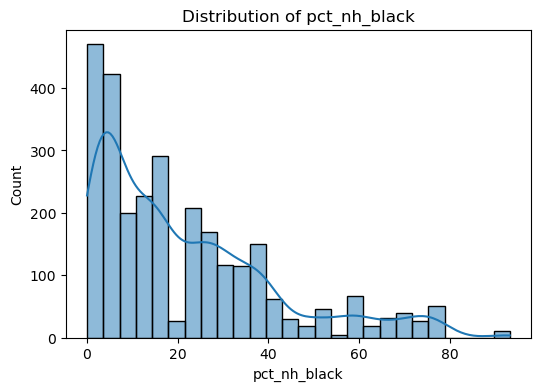

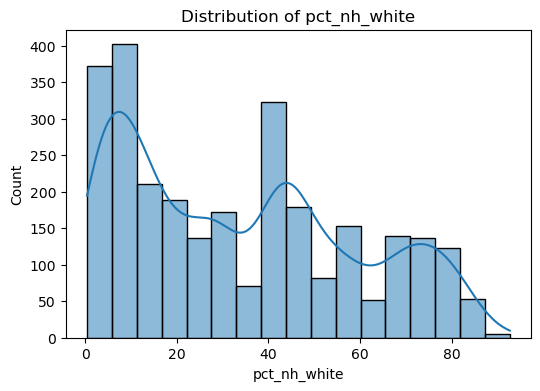

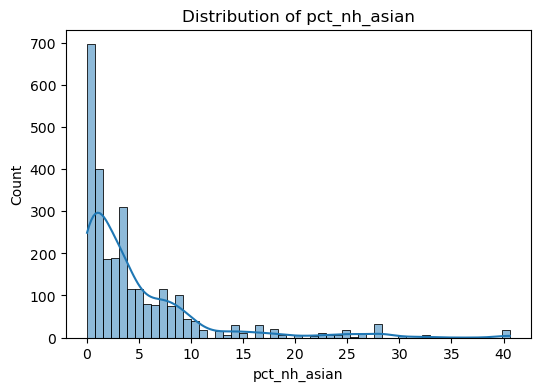

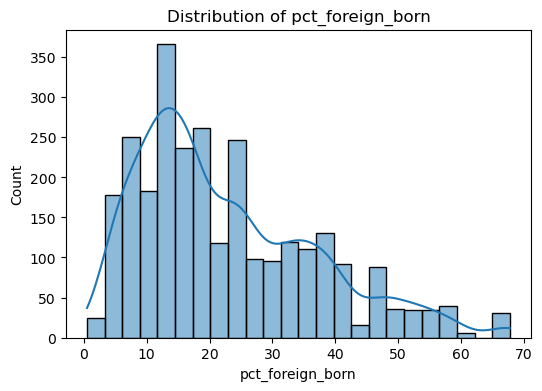

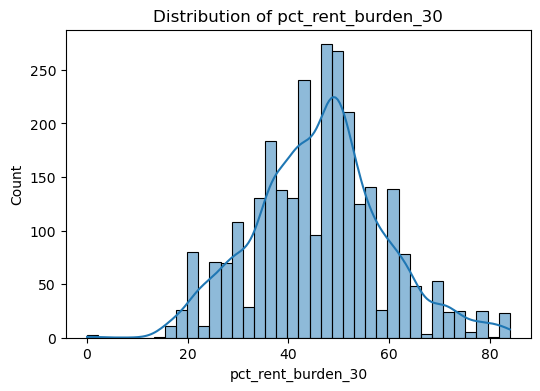

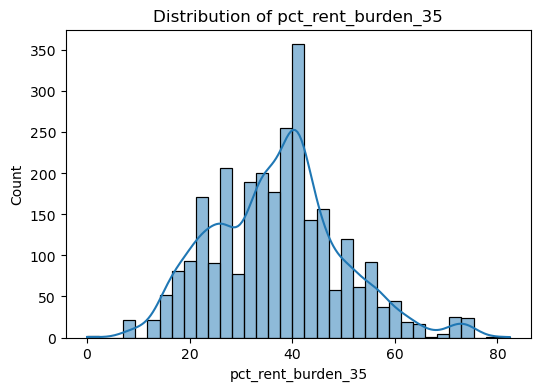

In [13]:
##distribution plot 
##plot
df.columns
candidate_features = [
    'score_current',
    'score_min',
    'score_max',
    'score_mean',
    'n_inspections',
    'n_bottom10',
    'life_hazard',
    'score_range',
    'chronic',
    'pct_poverty',
    'pct_renter',
    'pct_hispanic',
    'pct_nh_black',
    'pct_nh_white',
    'pct_nh_asian',
    'pct_foreign_born',
    'pct_rent_burden_30',
    'pct_rent_burden_35'
]
import matplotlib.pyplot as plt
import seaborn as sns

for col in candidate_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()



## 3. Build the feature matrix

_TODO:_ Select the **usable** features from the data dictionary — NOT the score-derived / flag columns (those leak the answer). Handle missing values. Optionally merge `n_units` from `property_profiles.csv`. (Task 4.)

## 4. Train/test split

_TODO:_ A random split, stratified on `bottom10`. (Task 5.)

## 5. Train models

_TODO:_ Baseline logistic regression / LASSO, then RandomForest and XGBoost. (Tasks 6–7.)

## 6. Evaluate

_TODO:_ Precision-recall AUC (the headline metric), ROC-AUC, and a confusion matrix. (Task 8.)

## 7. Feature importances

_TODO:_ Plot feature importances from the best model and save the figure to `../_output/`. (Task 9.)

## 8. Write-up

_TODO:_ A few paragraphs comparing your results to Chelsea's. **Remember the caveat:** Dallas inspects every multitenant property, so this model describes which profiles are associated with distress — not where to inspect next. (Task 10.)